<a href="https://colab.research.google.com/github/MoeezAmir93/deeplearning/blob/main/Copy_of_oel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1: KAGGLE SETUP (Upload kaggle.json first)
import os
from google.colab import files
files.upload()  # Upload kaggle.json file

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

Saving kaggle.json to kaggle.json


In [ ]:
# STEP 2: Download and Extract Fruits-360 Dataset
!kaggle datasets download -d moltean/fruits --force
!unzip -q fruits.zip

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
 99% 3.45G/3.47G [00:58<00:00, 120MB/s] 
100% 3.47G/3.47G [00:58<00:00, 63.8MB/s]


In [ ]:
# STEP 3: Verify Dataset Structure
!ls fruits-360_100x100/fruits-360/Training | head

Apple 10
Apple 11
Apple 12
Apple 13
Apple 14
Apple 17
Apple 18
Apple 19
Apple 5
Apple 6


In [ ]:
# STEP 4: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import models, layers, optimizers

Selected classes: ['Apple Red 1', 'Banana Lady Finger 1', 'Kiwi 1', 'Orange 1', 'Pear Williams 1']
Found 1200 images belonging to 5 classes.
Found 300 images belonging to 5 classes.
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.4751 - loss: 1.3737 - val_accuracy: 0.9700 - val_loss: 0.3567
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9442 - loss: 0.2812 - val_accuracy: 1.0000 - val_loss: 0.1430
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9827 - loss: 0.1332 - val_accuracy: 1.0000 - val_loss: 0.0831
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9928 - loss: 0.0810 - val_accuracy: 1.0000 - val_loss: 0.0553
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9980 - loss: 0.0557 - val_accuracy: 1.0000 - val_loss: 0.0425
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.5980 - loss: 0.9825 - val_accuracy: 1.0000 - val_loss: 0.0305
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.

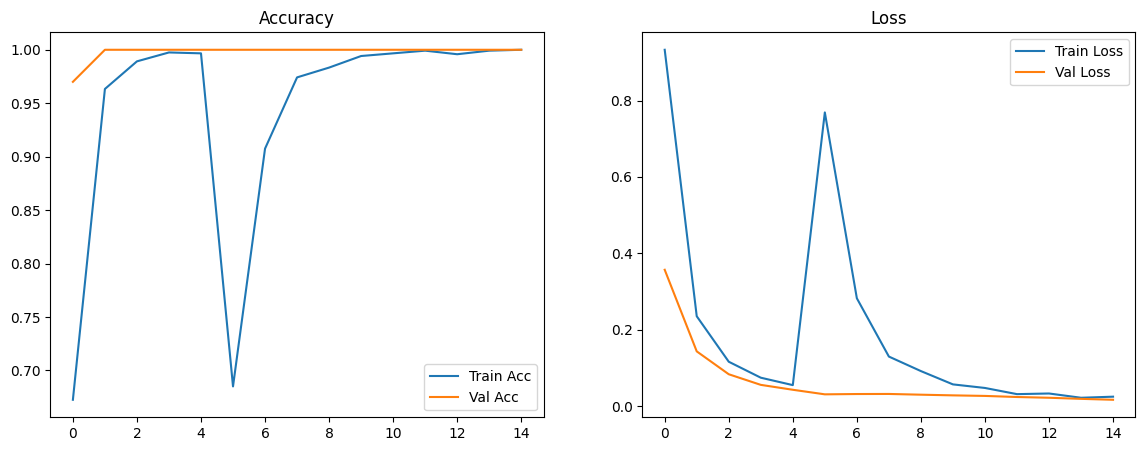

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


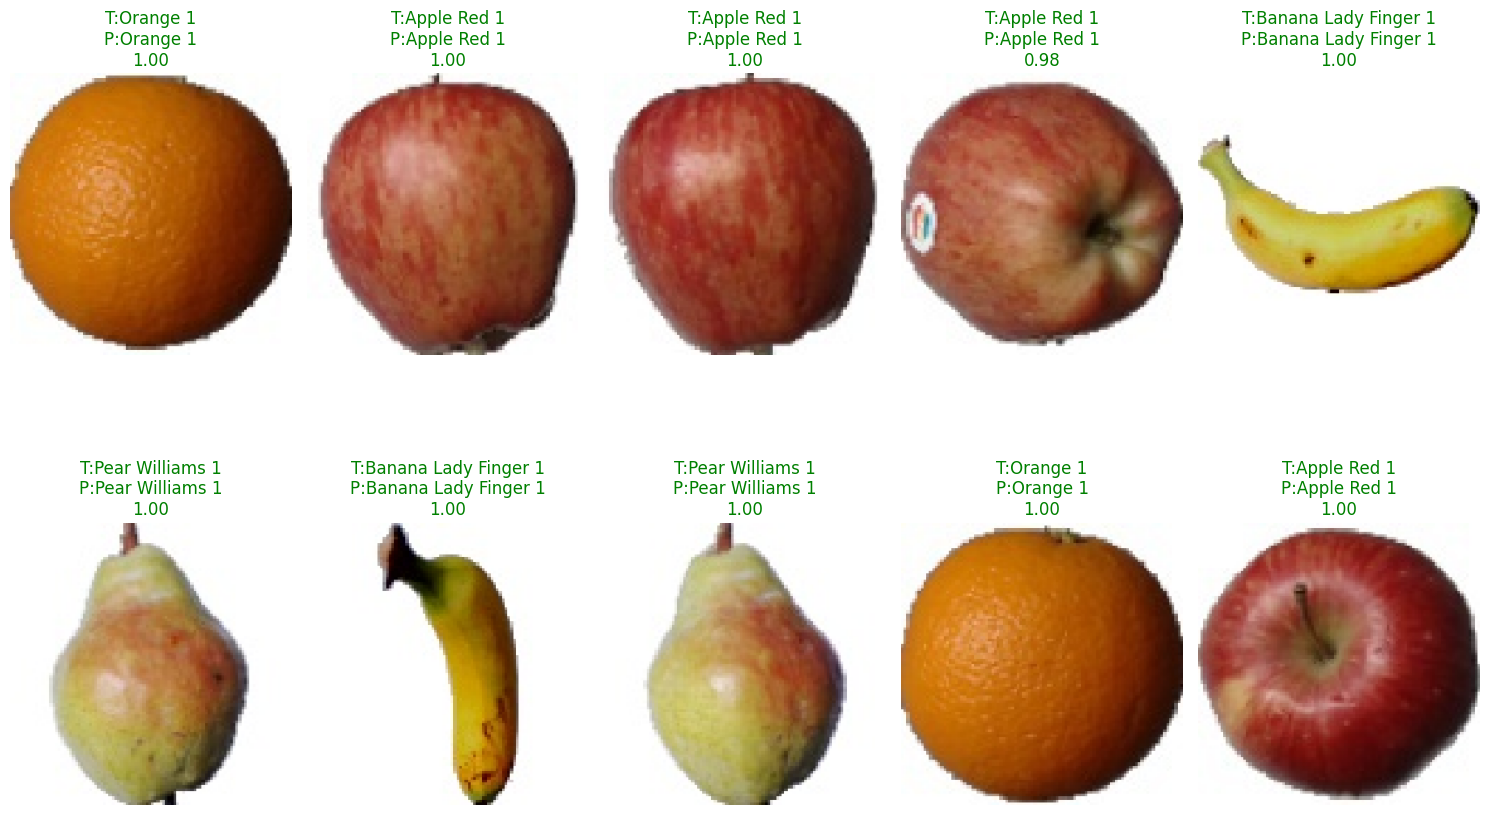

Selected classes: ['Apple Red 1', 'Banana Lady Finger 1', 'Kiwi 1', 'Orange 1', 'Pear Williams 1']
Found 1200 images belonging to 5 classes.
Found 300 images belonging to 5 classes.
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.3858 - loss: 1.5958 - val_accuracy: 0.9767 - val_loss: 0.4009
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9259 - loss: 0.3492 - val_accuracy: 0.9933 - val_loss: 0.1685
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9812 - loss: 0.1548 - val_accuracy: 1.0000 - val_loss: 0.0937
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.9966 - loss: 0.0938 - val_accuracy: 1.0000 - val_loss: 0.0664
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9932 - loss: 0.0600 - val_accuracy: 1.0000 - val_loss: 0.0503
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.6339 - loss: 0.8610 - val_accuracy: 1.0000 - val_loss: 0.0338
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9

In [ ]:
# STEP 5: Data Preparation
IMG_SIZE = 224
BATCH_SIZE = 32
data_dir = 'fruits-360_100x100/fruits-360/Training'
all_classes = ['Apple Red 1', 'Banana Lady Finger 1', 'Kiwi 1', 'Orange 1', 'Pear Williams 1']
print("Selected classes:", all_classes)

# Create folders for training and validation
os.makedirs('dataset/train', exist_ok=True)
os.makedirs('dataset/val', exist_ok=True)

for cls in all_classes:
    os.makedirs(f'dataset/train/{cls}', exist_ok=True)
    os.makedirs(f'dataset/val/{cls}', exist_ok=True)

    full_class_path = os.path.join(data_dir, cls)
    if not os.path.exists(full_class_path):
        raise FileNotFoundError(f"Class folder not found: {full_class_path}")

    img_files = os.listdir(full_class_path)[:300]
    train_imgs, val_imgs = train_test_split(img_files, test_size=0.2, random_state=42)

    for img in train_imgs:
        tf.io.gfile.copy(os.path.join(full_class_path, img), f'dataset/train/{cls}/{img}', overwrite=True)
    for img in val_imgs:
        tf.io.gfile.copy(os.path.join(full_class_path, img), f'dataset/val/{cls}/{img}', overwrite=True)

# STEP 6: Image Data Generators
train_gen = ImageDataGenerator(rescale=1./255, zoom_range=0.2, rotation_range=20, horizontal_flip=True)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory('dataset/train', target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical')
val_data = val_gen.flow_from_directory('dataset/val', target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical')

# STEP 7: Build MobileNetV2 Model
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(train_data.class_indices), activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

# STEP 8: Train (Transfer Learning)
history1 = model.fit(train_data, validation_data=val_data, epochs=5)

# STEP 9: Fine-Tune the Model
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history2 = model.fit(train_data, validation_data=val_data, epochs=10)

# STEP 10: Plot Accuracy & Loss
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    epochs = range(len(acc))
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_history(history1, history2)

# STEP 11: Show Predictions with Confidence
class_names = list(train_data.class_indices.keys())
images, labels = next(val_data)
preds = model.predict(images)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(15, 10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    pred_class = class_names[pred_labels[i]]
    true_class = class_names[true_labels[i]]
    confidence = np.max(preds[i])
    color = "green" if pred_class == true_class else "red"
    plt.title(f'T:{true_class}\nP:{pred_class}\n{confidence:.2f}', color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()
